# Process Sentinel-1 partial products

This tutorial processes an InSAR pair from `.partial.SAFE` products created by `s1-partial-product-download.ipynb`.

Key behavior to remember:

- A partial product carries its own `partial_aoi.geojson`.
- A partial product also carries `partial_download.yml`, an EO-Tools manifest that is not part of the standard Sentinel-1 SAFE format.
- User-facing processors use the stored AOI automatically for valid partial products. If `shp` is supplied, it is ignored and the internal `partial_aoi.geojson` is used instead.
- InSAR partial processing currently requires both products to be partial products with identical stored AOIs and matching downloaded IW/polarization subsets.
- Burst overlap and burst-index offsets are checked later in preprocessing.

## 1. Imports and paths

In [1]:
import logging
from pathlib import Path

import rioxarray as riox

from eo_tools.S1.core import read_partial_aoi, read_partial_download_info
from eo_tools.S1.process import process_insar

logging.basicConfig(level=logging.INFO)
logging.getLogger("httpx").setLevel(logging.WARNING)

In [2]:
data_dir = Path("/data/S1/partial_dls")
output_root = Path("/data/res/tutorial-s1-partial-products")
output_root.mkdir(parents=True, exist_ok=True)

ids = [
    "S1A_IW_SLC__1SDV_20230904T063730_20230904T063757_050174_0609E3_DAA1",
    "S1A_IW_SLC__1SDV_20230916T063730_20230916T063757_050349_060FCD_6814",
]

primary_path = data_dir / f"{ids[0]}.partial.SAFE"
secondary_path = data_dir / f"{ids[1]}.partial.SAFE"

for path in (primary_path, secondary_path):
    if not path.is_dir():
        raise FileNotFoundError(
            f"Missing partial product: {path}. Run the partial-product download tutorial first."
        )

primary_path, secondary_path

(PosixPath('/data/S1/partial_dls/S1A_IW_SLC__1SDV_20230904T063730_20230904T063757_050174_0609E3_DAA1.partial.SAFE'),
 PosixPath('/data/S1/partial_dls/S1A_IW_SLC__1SDV_20230916T063730_20230916T063757_050349_060FCD_6814.partial.SAFE'))

## 2. Optionally inspect the partial metadata

This inspection step is optional and is included to show what EO-Tools stores alongside a partial product. `partial_download.yml` is an EO-Tools-specific manifest, not a standard SAFE file. The processor reads it automatically to validate requested subswaths, polarizations, and available bursts, and reads `partial_aoi.geojson` as the processing AOI.

In [3]:
primary_manifest = read_partial_download_info(primary_path)
secondary_manifest = read_partial_download_info(secondary_path)
primary_aoi = read_partial_aoi(primary_path, primary_manifest)
secondary_aoi = read_partial_aoi(secondary_path, secondary_manifest)

print(primary_manifest)
print(f"Primary and secondary stored AOIs are equal: {primary_aoi.equals_exact(secondary_aoi, 0)}")

{'product_id': 'S1A_IW_SLC__1SDV_20230904T063730_20230904T063757_050174_0609E3_DAA1', 'aoi_file': 'partial_aoi.geojson', 'subsets': {'iw1': {'vv': {'file': 'measurement/s1a-iw1-slc-vv-20230904t063731-20230904t063756-050174-0609e3-004.tiff', 'min_burst': 1, 'max_burst': 1, 'line_start': 0, 'number_of_lines': 1507, 'lines_per_burst': 1507}, 'vh': {'file': 'measurement/s1a-iw1-slc-vh-20230904t063731-20230904t063756-050174-0609e3-001.tiff', 'min_burst': 1, 'max_burst': 1, 'line_start': 0, 'number_of_lines': 1507, 'lines_per_burst': 1507}}, 'iw2': {'vv': {'file': 'measurement/s1a-iw2-slc-vv-20230904t063732-20230904t063757-050174-0609e3-005.tiff', 'min_burst': 1, 'max_burst': 1, 'line_start': 0, 'number_of_lines': 1519, 'lines_per_burst': 1519}, 'vh': {'file': 'measurement/s1a-iw2-slc-vh-20230904t063732-20230904t063757-050174-0609e3-002.tiff', 'min_burst': 1, 'max_burst': 1, 'line_start': 0, 'number_of_lines': 1519, 'lines_per_burst': 1519}}}}
Primary and secondary stored AOIs are equal: Tru

For partial products, high-level processors use the internal `partial_aoi.geojson` stored in the product folder. The processing call below therefore does not pass a separate AOI. If a `shp` parameter is supplied, it is ignored for partial products and does not override the internal GeoJSON.

## 3. Process an InSAR pair

For the initial partial-product release, InSAR processing is intentionally strict: both inputs must be partial products with equal stored AOIs and matching downloaded IW/polarization subsets. If the secondary product cannot provide the offset-mapped bursts needed by the primary-selected range, preprocessing raises a clear error.

In [ ]:
insar_dir = process_insar(
    prm_path=str(primary_path),
    sec_path=str(secondary_path),
    output_dir=str(output_root / "insar"),
    aoi_name=None,
    pol="vv",
    subswaths=["IW1", "IW2", "IW3"],
    write_coherence=True,
    write_interferogram=True,
    write_primary_amplitude=False,
    write_secondary_amplitude=False,
    apply_fast_esd=True,
    dem_upsampling=1.8,
    dem_force_download=False,
    dem_buffer_arc_sec=40,
    boxcar_coherence=[3, 3],
    filter_ifg=True,
    multilook=[1, 4],
    warp_kernel="bicubic",
    cal_type="beta",
    clip_to_shape=True,
    orb_dir="/data/S1_orbits/",
)

insar_dir

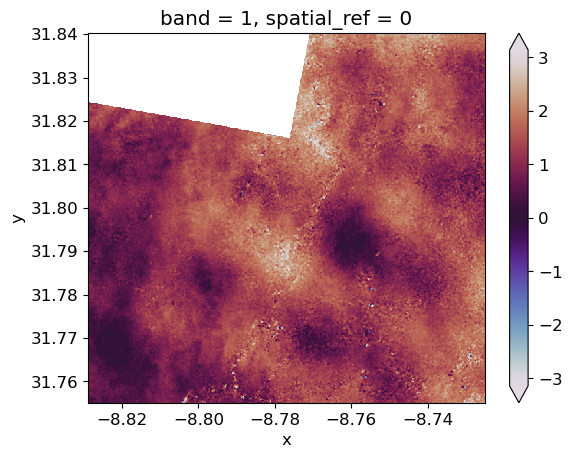

In [5]:
arr_phi = riox.open_rasterio(f"{insar_dir}/phi_vv.tif", masked=True)[0]
arr_phi.plot.imshow(vmin=-3.14, vmax=3.14, cmap="twilight")

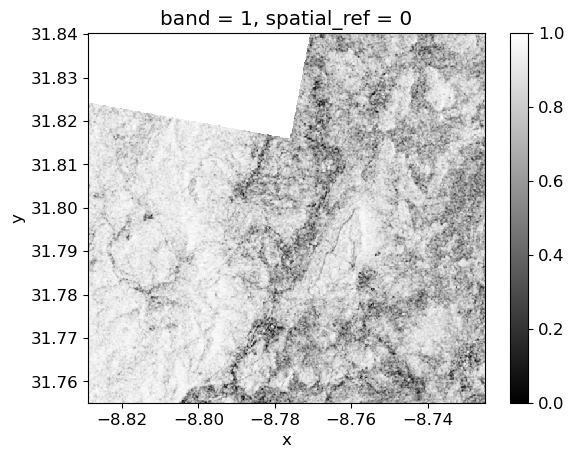

In [6]:
arr_coh = riox.open_rasterio(f"{insar_dir}/coh_vv.tif", masked=True)[0]
arr_coh.plot.imshow(vmin=0, vmax=1, cmap="gray")

## Troubleshooting

- `Missing partial product`: run the download tutorial first and check `data_dir`.
- `requested polarization/subswath is not available`: re-download the partial product with the required `pol` selection.
- `secondary partial product does not contain required bursts`: the primary AOI-selected bursts do not all have offset-mapped secondary data available; re-download a compatible pair or use a smaller AOI.
- no common burst found although both STAC footprints overlap each other and the AOI: STAC product footprints do not represent the exact Sentinel-1 burst geometries. Use `eo_tools.auxils.get_burst_geometry(...)` to inspect the individual product burst geometries and select a compatible pair.
- unexpected clipping or geocoding extent: inspect `partial_aoi.geojson`; this AOI is the processing reference for partial products.